# 5-Supervised Learning : rating prediction

In this notebook, we build supervised machine learning models to predict the rating (number of stars) based on the review text.
We start with a classical NLP approach using TF-IDF features and logistic regression and evaluate the model performance.
This step allows us to assess how well textual information can explain customer ratings.

Imports


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [2]:
df = pd.read_csv("../data/processed/reviews_supervised.csv")
df.shape

(24104, 14)

The dataset used for supervised learning "df_supervised" is derived from the cleaned dataset by removing all rows with missing ratings (`note`).
This step is necessary because supervised learning requires labeled data.

Check

In [3]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file,avis_clean,avis_clean_fr
0,5,claire-m-130353,"les prix au top, la facilité d'inscription et ...",Direct Assurance,auto,train,2021-08-31,2021-08-01,"top prices, ease of registration and clear ser...",NaN,NaN,avis_21_traduit.xlsx,les prix au top la facilité d inscription et l...,les prix au top la facilité d inscription et l...
1,2,tontonlouis-90075,je n'ai pas les moyens d'attendre 3 à 4 semain...,Cegema Assurances,sante,train,2020-05-30,2020-05-01,I cannot afford to wait 3 to 4 weeks for reimb...,NaN,NaN,avis_21_traduit.xlsx,je n ai pas les moyens d attendre 3 à 4 semain...,je n ai pas les moyens d attendre 3 à 4 semain...
2,1,fred78-132197,Je voulais assurer une Tesla Modèle 3 LR ...\n...,MACIF,auto,train,2021-09-10,2021-09-01,I wanted to ensure a Tesla Model 3 LR ...\nThe...,NaN,NaN,avis_21_traduit.xlsx,je voulais assurer une tesla modèle 3 lr le pr...,je voulais assurer une tesla modèle 3 lr le pr...
3,1,sud-70690,"Je suis en arrêt de travail depuis nov 2017 ,a...",Cardif,credit,train,2019-02-07,2019-02-01,"I am on work stoppage since Nov 2017, assured ...",NaN,NaN,avis_21_traduit.xlsx,je suis en arrêt de travail depuis nov 2017 as...,je suis en arrêt de travail depuis nov 2017 as...
4,1,fofi-80683,inadmissible... je leur ai réglé un trop perçu...,Harmonie Mutuelle,sante,train,2019-11-04,2019-11-01,Inadmissible ... I set them too perceived foll...,NaN,NaN,avis_21_traduit.xlsx,inadmissible je leur ai réglé un trop perçu su...,inadmissible je leur ai réglé un trop perçu su...


Prepare the data

In [4]:
# features and target
X = df["avis_clean"]
y = df["note"]

Test and split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #we use stratify to maintain class distribution in train and test sets

STOPWORDS

Before applying TF_IDF we will delete all the stopword who could reduce the explainabality 

In [6]:

%pip install spacy
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

nlp = spacy.load("fr_core_news_sm") # this model gives us access to a list of french stopwords
custom_stopwords = set(nlp.Defaults.stop_words)

custom_stopwords = custom_stopwords - {"pas", "ne", "jamais"} # keep negation words because they are important for sentiment analysis

# add extra domain specific words that are too generic
custom_stopwords.update(["de", "la", "le", "les", "des", "du","un", "une", "et", "en", "je", "vous","ils", "elles", "nous", "qui", "que",
    "pour", "avec", "être", "été"])

Note: you may need to restart the kernel to use updated packages.


/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF-IDF

##### Improved Text Representation

We refine the TF-IDF representation by:

- removing common french stopwords to reduce noise,
- removing rare words (min_df) that do not generalize well,
- removing very frequent words (max_df) that carry little information.
- change from 2gram to 3gram

This allows the model to focus on more meaningful and discriminative terms.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1,3),stop_words=list(custom_stopwords),min_df=5,max_df=0.9)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(



TF-IDF stands for (Term Frequency - Inverse Document Frequency).
It is a method used to convert text into numerical features that can be used by machine learning models.

It works by assigning a weight to each word based on:
- how often the word appears in a document (Term frequency),
- how rare the word is across all documents (Inverse document frequency).

The main idea is to give higher importance to words that are frequent in a specific review but not common across all reviews.
This allows the model to focus on meaningful and discriminative words rather than very common words that carry little information.

### Logistic Regression

In [8]:
model = LogisticRegression(max_iter=1000) #we start with a simple logistic regression model for classification and add class weight to handle class imbalance.
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [9]:
y_pred = model.predict(X_test_tfidf)

Evaluation

In [10]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.5140012445550716

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.61      0.86      0.71      1454
           2       0.36      0.20      0.25       743
           3       0.29      0.17      0.21       677
           4       0.44      0.42      0.43       977
           5       0.54      0.57      0.56       970

    accuracy                           0.51      4821
   macro avg       0.45      0.44      0.43      4821
weighted avg       0.48      0.51      0.48      4821



Confusion Matrix

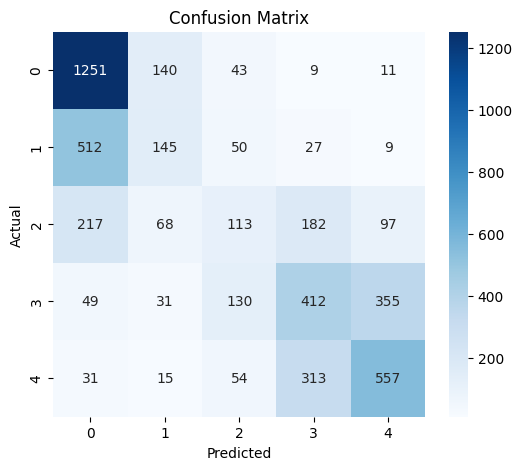

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Naive Bayes 

We test a multinomial naive bayes model which is well suited for text classification tasks based on word frequencies.
This model is simple, fast and often performs well as a baseline in NLP problems.

In [13]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

y_pred_nb = model_nb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.5110972827214271
              precision    recall  f1-score   support

           1       0.55      0.94      0.70      1454
           2       0.33      0.05      0.08       743
           3       0.32      0.09      0.14       677
           4       0.44      0.41      0.42       977
           5       0.53      0.62      0.57       970

    accuracy                           0.51      4821
   macro avg       0.43      0.42      0.38      4821
weighted avg       0.46      0.51      0.44      4821



### LinearSVC

We test a Linear support vector machine (LinearSVC) which is known to perform very well on high dimensional sparse data such as TF-IDF representations.
This model aims to find the optimal boundary between classes in the feature space.

In [14]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train_tfidf, y_train)

y_pred_svm = model_svm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.5052893590541382
              precision    recall  f1-score   support

           1       0.60      0.86      0.71      1454
           2       0.33      0.18      0.23       743
           3       0.28      0.12      0.16       677
           4       0.42      0.42      0.42       977
           5       0.52      0.59      0.55       970

    accuracy                           0.51      4821
   macro avg       0.43      0.43      0.41      4821
weighted avg       0.46      0.51      0.47      4821



Although the performance remains moderate, it is clearly above random guessing(20 % because there is 5 classes). However the models still struggle with intermediate ratings which remain difficult to distinguish.

### XGBOOST

In [15]:
%pip install xgboost

  Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl (1.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [18]:
from xgboost import XGBClassifier

# we got an error because Xgboost requires labels starting from 0 instead of 1
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

model_xgb = XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,objective="multi:softmax",num_class=5,eval_metric="mlogloss",use_label_encoder=False)
model_xgb.fit(X_train_tfidf, y_train_xgb)

y_pred_xgb = model_xgb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:19:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.12404065546567103
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.38      0.03      0.05      1454
           2       0.11      0.02      0.03       743
           3       0.21      0.33      0.26       677
           4       0.32      0.33      0.33       977
           5       0.00      0.00      0.00       970

    accuracy                           0.12      4821
   macro avg       0.17      0.12      0.11      4821
weighted avg       0.23      0.12      0.12      4821



/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

### BERT

BERT uses contextual embeddings, allowing it to understand the meaning of words depending on their context.
This makes it more powerful than classical models based on word frequency.

In [ ]:
%pip install transformers datasets torch

  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-21.0.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (3.3 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py39-none-any.whl.metadata (7.5 kB)
  Using cached aiohttp-3.13.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached frozenlist-1.8.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.3 kB)
  Using cached propcache-0.4.1-cp39-cp39-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached yarl-1.22.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (75 kB)
Using cached datasets-4.5.0-py3-none-any

In [ ]:
from transformers import pipeline

classifier = pipeline("text-classification", model="nlptown/bert-base-multilingual-uncased-sentiment") #from Hugging Face, this model is trained on multilingual reviews and can predict sentiment from 1 to 5 stars

preds = classifier(list(X_test[:10]))

preds

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use mps:0


[{'label': '4 stars', 'score': 0.46167001128196716},
 {'label': '3 stars', 'score': 0.41538339853286743},
 {'label': '1 star', 'score': 0.6042366623878479},
 {'label': '5 stars', 'score': 0.7373514771461487},
 {'label': '5 stars', 'score': 0.5011892914772034},
 {'label': '1 star', 'score': 0.665805995464325},
 {'label': '4 stars', 'score': 0.5675100088119507},
 {'label': '3 stars', 'score': 0.49556535482406616},
 {'label': '1 star', 'score': 0.49687403440475464},
 {'label': '1 star', 'score': 0.7265059351921082}]